# Importing warnings library

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zonelookup_file_path = '/content/drive/MyDrive/NYC dataset/taxi_zone_lookup.csv'

try:
    df_zones = pd.read_csv(zonelookup_file_path)
    print("Zonelookup table loaded successfully!")
    display(df_zones.head())
except FileNotFoundError:
    print(f"Error: The file at '{zonelookup_file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Zonelookup table loaded successfully!


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
import pandas as pd

# Replace 'YOUR_FILE_PATH_HERE' with the actual path to your file in Google Drive
file_path = '/content/drive/MyDrive/NYC dataset/Yellow_taxi_2025.parquet'

try:
    # Assuming it's a CSV file. If it's a different format (e.g., Excel, JSON),
    # you'll need to use the appropriate pandas read function (e.g., pd.read_excel, pd.read_json).
    df = pd.read_parquet(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please double-check the path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

File loaded successfully!


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,Borough,Zone,service_zone,fare_per_mile,tip_pct(%),trip_duration_minutes,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
0,2,2025-02-01 00:12:18,2025-02-01 00:32:33,3.0,3.12,1.0,246,79,1,19.799999,...,Manhattan,West Chelsea/Hudson Yards,Yellow Zone,6.346154,0.258049,20.250000,5,0,2,1
1,2,2025-02-01 00:40:04,2025-02-01 00:49:15,1.0,1.40,1.0,114,79,1,10.000000,...,Manhattan,Greenwich Village South,Yellow Zone,7.142857,0.315039,9.183333,5,0,2,1
2,1,2025-02-01 00:06:09,2025-02-01 00:11:51,1.0,0.40,1.0,211,144,1,6.500000,...,Manhattan,SoHo,Yellow Zone,16.250000,0.153846,5.700000,5,0,2,1
3,1,2025-02-01 00:15:13,2025-02-01 00:20:19,1.0,0.70,1.0,113,249,1,7.200000,...,Manhattan,Greenwich Village North,Yellow Zone,10.285714,0.277778,5.100000,5,0,2,1
4,2,2025-02-01 00:02:52,2025-02-01 00:20:25,1.0,4.19,1.0,113,263,1,19.799999,...,Manhattan,Greenwich Village North,Yellow Zone,4.725537,0.258049,17.550000,5,0,2,1


# importing necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Viewing the dataset
df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,LocationID,Borough,Zone,service_zone
13207673,2,2025-05-06 21:21:27,2025-05-06 21:25:32,1.0,0.72,1.0,113,90,1,6.5,...,0.0,1.0,14.699219,2.5,0.0,0.75,113,Manhattan,Greenwich Village North,Yellow Zone
13426199,2,2025-05-09 01:49:17,2025-05-09 01:55:32,4.0,1.19,1.0,144,79,1,8.6,...,0.0,1.0,17.219141,2.5,0.0,0.75,144,Manhattan,Little Italy/NoLiTa,Yellow Zone
17377882,2,2025-01-16 20:35:36,2025-01-16 20:41:34,3.0,0.87,1.0,152,166,1,7.9,...,0.0,1.0,11.959570,0.0,0.0,0.00,152,Manhattan,Manhattanville,Boro Zone
7445670,1,2025-03-16 10:00:36,2025-03-16 10:09:22,1.0,0.70,1.0,162,140,1,7.2,...,0.0,1.0,18.200001,2.5,0.0,0.75,162,Manhattan,Midtown East,Yellow Zone
2316047,2,2025-02-28 18:19:12,2025-02-28 18:31:41,1.0,2.53,1.0,79,232,1,14.9,...,0.0,1.0,23.150000,2.5,0.0,0.75,79,Manhattan,East Village,Yellow Zone


In [ ]:
# checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18962717 entries, 0 to 18998027
Data columns (total 30 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float16       
 4   trip_distance          float32       
 5   RatecodeID             float16       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   payment_type           uint16        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  total_amount           float32       
 16  congestion_surcharge   float16       
 17  Airport_fee            float16       
 18  cbd_congestion_fee     fl

# Selecting only important features for analysis

In [ ]:
df = df[['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'payment_type', 'trip_distance', 'PULocationID', 'DOLocationID', 'Zone', 'fare_amount','extra', 'mta_tax', 'tip_amount','tolls_amount','improvement_surcharge', 'Airport_fee','cbd_congestion_fee', 'congestion_surcharge', 'total_amount',  'Borough', 'pickup_day_of_week', 'pickup_hour', 'pickup_month', 'is_weekend']]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18962717 entries, 0 to 18998027
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float16       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   Zone                   object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float16       
 16  cbd_congestion_fee     float16       
 17  congestion_surcharge   float16       
 18  total_amount           fl

# Univariate analysis

non-categorical features = [
    'trip_distance', 'fare_amount', 'tip_amount',
    'congestion_surcharge',
    'Airport_fee', 'passenger_count', 'fare_per_mile'
]

# trip_distance

In [ ]:
# describe
df['trip_distance'].describe()

,trip_distance
count,1.896272e+07
mean,1.974483e+00
std,1.342178e+00
min,1.000000e-02
25%,1.000000e+00
50%,1.600000e+00
75%,2.560000e+00
max,7.150000e+00


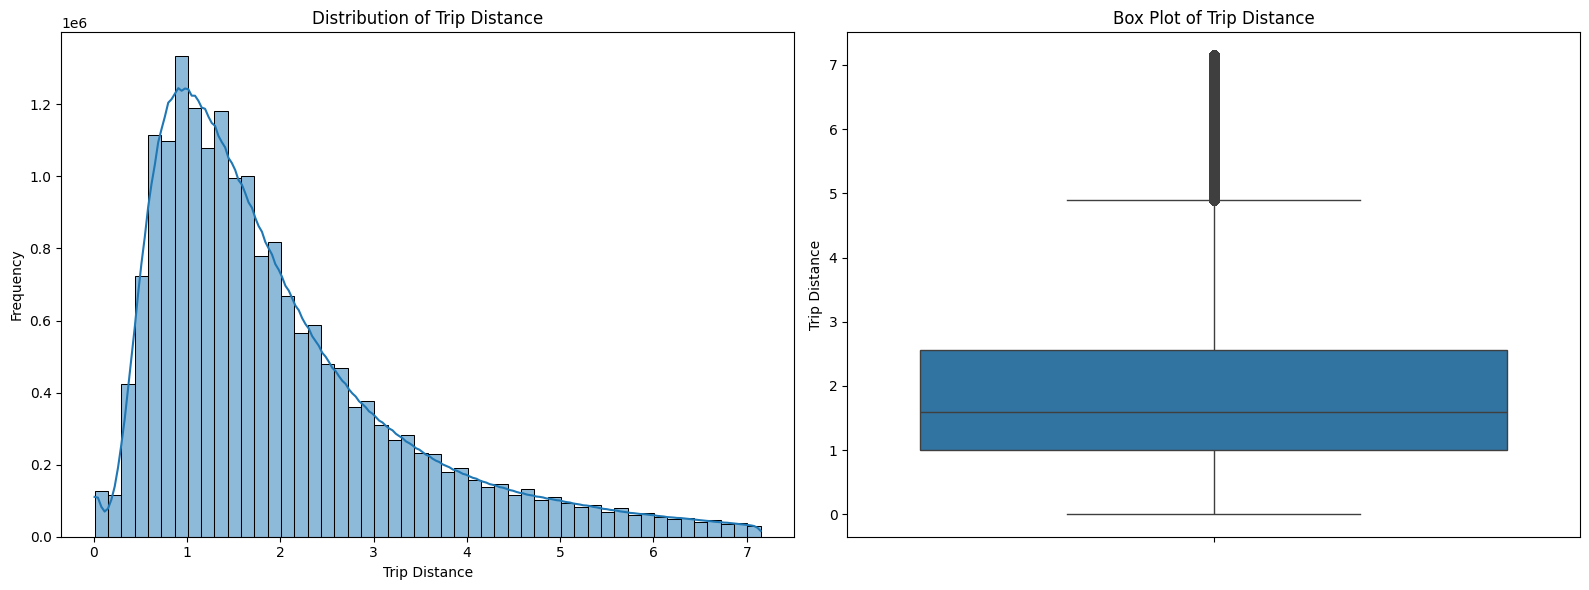

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['trip_distance'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Trip Distance')
axes[0].set_xlabel('Trip Distance')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['trip_distance'], ax=axes[1])
axes[1].set_title('Box Plot of Trip Distance')
axes[1].set_ylabel('Trip Distance')

plt.tight_layout()
plt.show()

The distribution is exponential with reight skewed data, with some outliers being detected statistically but in real world situation those values are possible.

# fare_amount

In [ ]:
df['fare_amount'].describe()

,fare_amount
count,1.896272e+07
mean,1.388960e+01
std,6.393426e+00
min,1.000000e-02
25%,8.600000e+00
50%,1.280000e+01
75%,1.770000e+01
max,3.310000e+01


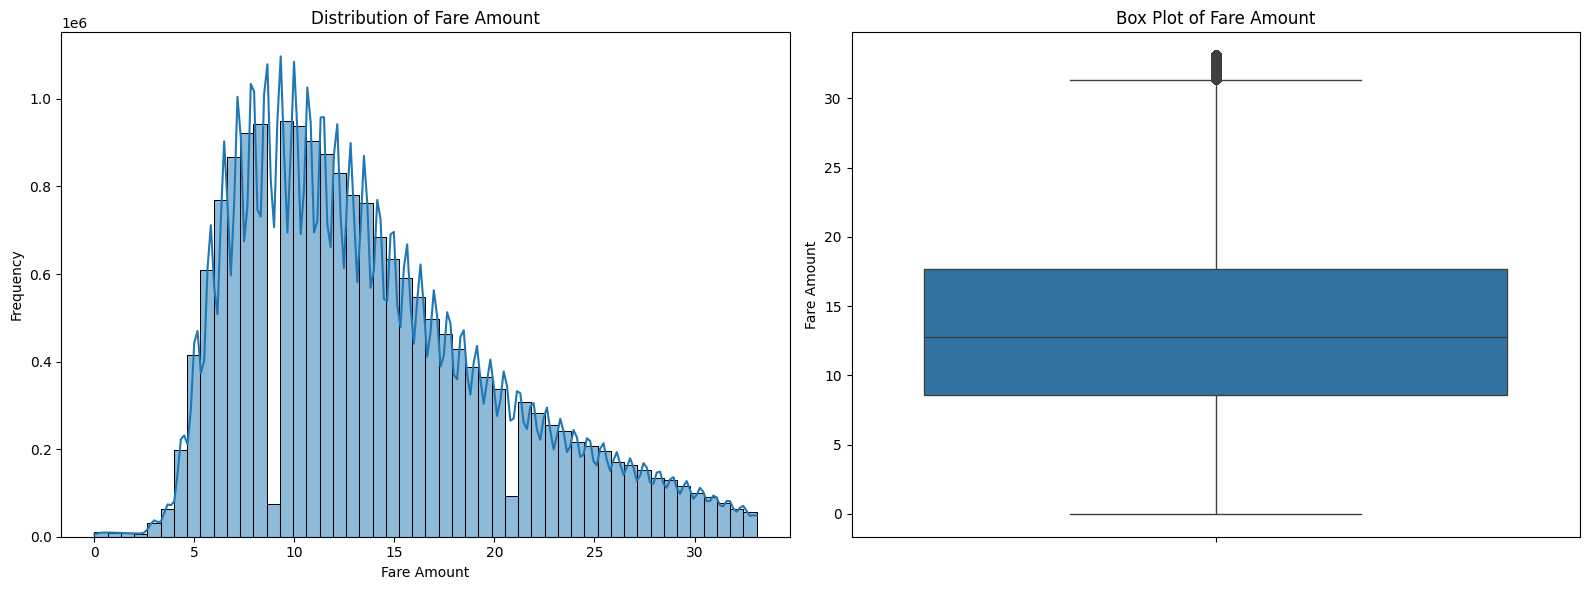

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['fare_amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlabel('Fare Amount')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['fare_amount'], ax=axes[1])
axes[1].set_title('Box Plot of Fare Amount')
axes[1].set_ylabel('Fare Amount')

plt.tight_layout()
plt.show()

The dsitribution seems a little bit right skewed with some amount of outliers present which are not unusual values in a real world scenario.

# tip_amount

In [ ]:
df['tip_amount'].describe()

,tip_amount
count,1.896272e+07
mean,NaN
std,0.000000e+00
min,0.000000e+00
25%,0.000000e+00
50%,2.250000e+00
75%,3.650391e+00
max,9.117188e+00


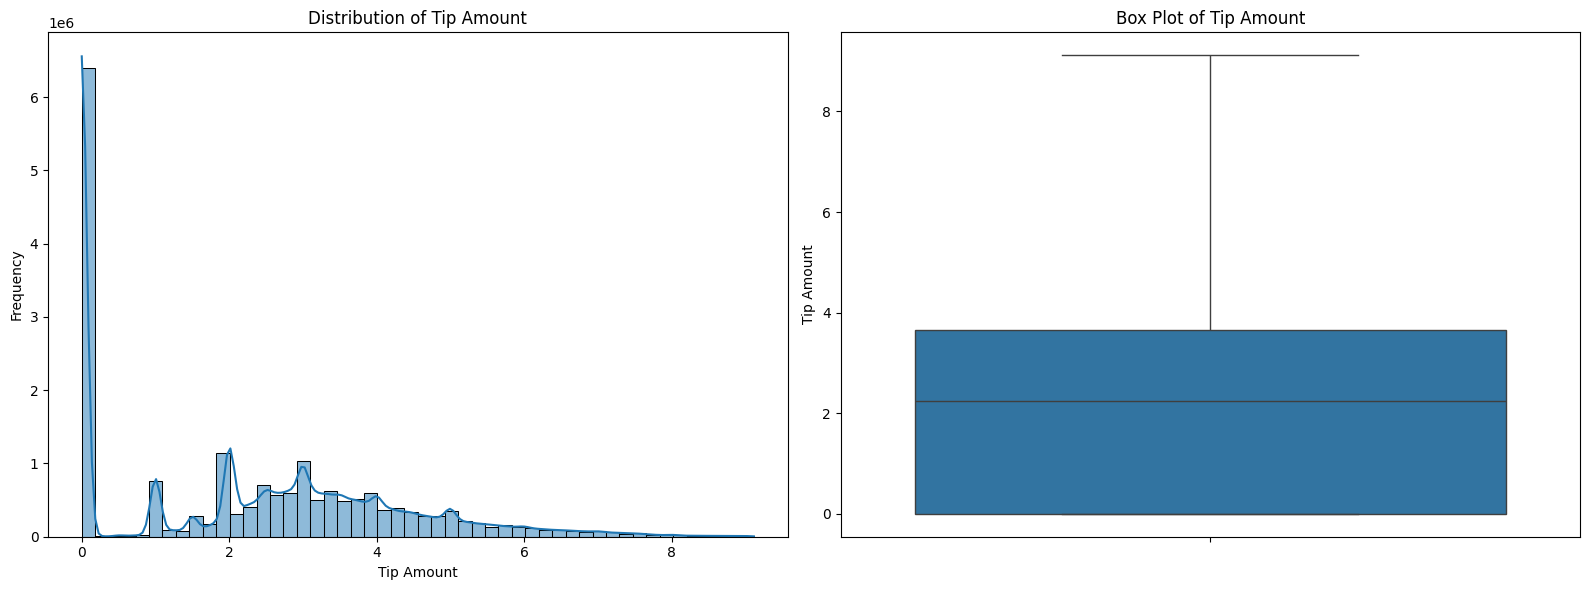

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['tip_amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Tip Amount')
axes[0].set_xlabel('Tip Amount')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['tip_amount'], ax=axes[1])
axes[1].set_title('Box Plot of Tip Amount')
axes[1].set_ylabel('Tip Amount')

plt.tight_layout()
plt.show()

The distribution is highly right skewed with max frequency of '0' amount, with no presence of outliers

# congestion_surcharge

In [ ]:
df['congestion_surcharge'].describe()

,congestion_surcharge
count,18962717.0
mean,NaN
std,0.0
min,0.0
25%,2.5
50%,2.5
75%,2.5
max,2.5


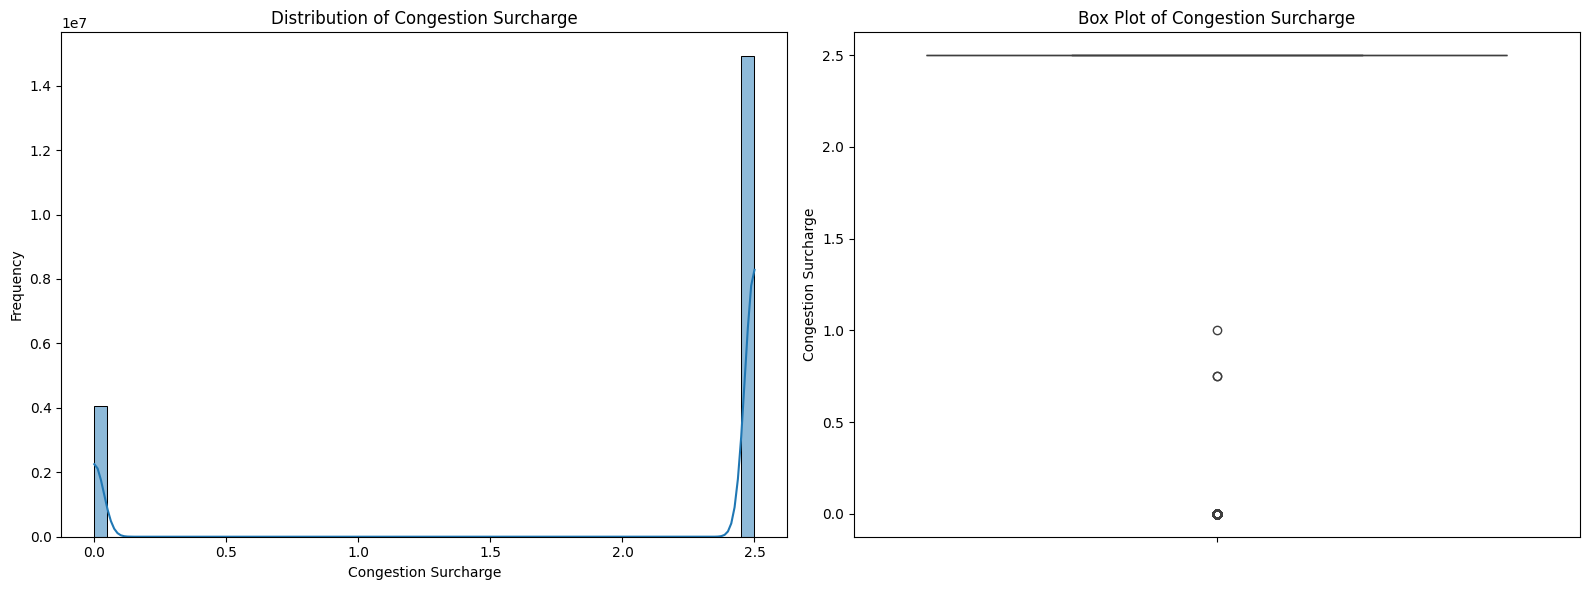

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['congestion_surcharge'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Congestion Surcharge')
axes[0].set_xlabel('Congestion Surcharge')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['congestion_surcharge'], ax=axes[1])
axes[1].set_title('Box Plot of Congestion Surcharge')
axes[1].set_ylabel('Congestion Surcharge')

plt.tight_layout()
plt.show()

The max frequency is of '2.5' which is why any value less than that is being detected as outliers, still '0' value is possible since there may be scenarios where the congestion value is not applicable.

# Airport_fee

In [ ]:
df['Airport_fee'].describe()

,Airport_fee
count,18962717.00
mean,NaN
std,0.00
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,6.75


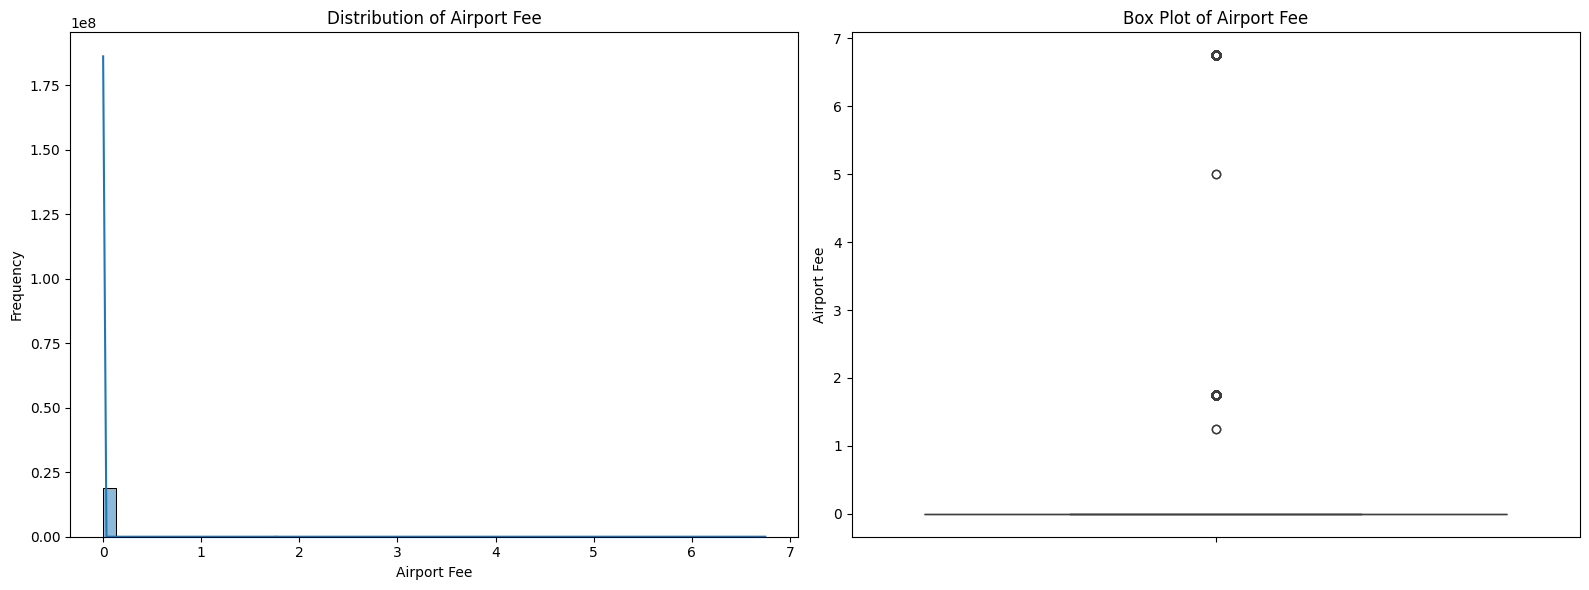

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['Airport_fee'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Airport Fee')
axes[0].set_xlabel('Airport Fee')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['Airport_fee'], ax=axes[1])
axes[1].set_title('Box Plot of Airport Fee')
axes[1].set_ylabel('Airport Fee')

plt.tight_layout()
plt.show()

The max frequency is of '0' value which is where we have seen is applicable only for the regions with airports and max regions is not associated with aiports that is why any value other than 0 is being detected as outliers we cannot simply drop these values since they are not unusual values.

# passenger_count

In [ ]:
df['passenger_count'].describe()

,passenger_count
count,18962717.0
mean,NaN
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,6.0


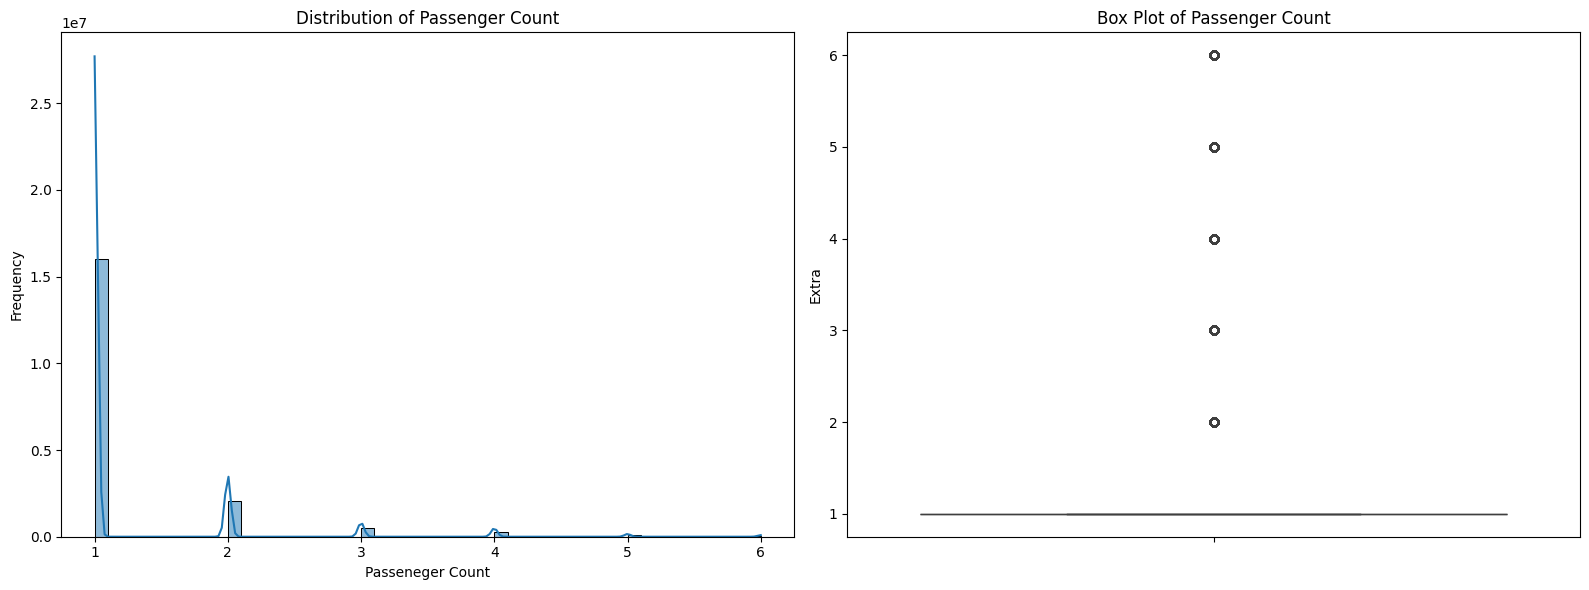

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['passenger_count'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Passenger Count')
axes[0].set_xlabel('Passeneger Count')
axes[0].set_ylabel('Frequency')

# Box plot (to easily see outliers)
sns.boxplot(y=df['passenger_count'], ax=axes[1])
axes[1].set_title('Box Plot of Passenger Count')
axes[1].set_ylabel('Extra')

plt.tight_layout()
plt.show()

The max number of customers boarded the taxi in a specific time is '1' 

# Outlier detection function

In [ ]:
def detect_outliers(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers

In [ ]:
# checking trip_distance outliers
outliers = detect_outliers(df, 'trip_distance')
outliers.nlargest(10, 'trip_distance')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
59003,2,2025-02-01 17:35:52,2025-02-01 17:58:08,2.0,1,7.15,87,140,Financial District North,31.000000,...,1.0,0.00,0.75,2.5,42.898438,Manhattan,5,17,2,1
60752,2,2025-02-01 17:21:44,2025-02-01 17:42:00,1.0,1,7.15,138,74,LaGuardia Airport,30.299999,...,1.0,1.75,0.00,2.5,46.049999,Queens,5,17,2,1
61557,2,2025-02-01 18:29:27,2025-02-01 18:49:00,1.0,1,7.15,138,41,LaGuardia Airport,31.700001,...,1.0,1.75,0.00,0.0,46.981251,Queens,5,18,2,1
86180,2,2025-02-01 22:11:07,2025-02-01 22:25:51,1.0,1,7.15,138,121,LaGuardia Airport,29.600000,...,1.0,1.75,0.00,0.0,42.849998,Queens,5,22,2,1
98957,2,2025-02-02 00:54:27,2025-02-02 01:18:57,3.0,1,7.15,239,114,Upper West Side South,33.099998,...,1.0,0.00,0.75,2.5,39.849998,Manhattan,6,0,2,1
103147,2,2025-02-02 01:50:54,2025-02-02 02:08:17,1.0,1,7.15,13,181,Battery Park City,30.299999,...,1.0,0.00,0.75,2.5,42.049999,Manhattan,6,1,2,1
111245,2,2025-02-02 03:51:54,2025-02-02 04:07:07,1.0,2,7.15,132,130,JFK Airport,29.600000,...,1.0,1.75,0.00,2.5,36.349998,Queens,6,3,2,1
116161,2,2025-02-02 09:49:51,2025-02-02 10:14:21,1.0,2,7.15,238,144,Upper West Side North,33.099998,...,1.0,0.00,0.75,2.5,37.849998,Manhattan,6,9,2,1
147157,2,2025-02-02 16:50:36,2025-02-02 17:06:28,2.0,2,7.15,13,141,Battery Park City,30.299999,...,1.0,0.00,0.75,2.5,35.049999,Manhattan,6,16,2,1
156335,2,2025-02-02 18:09:39,2025-02-02 18:31:24,1.0,2,7.15,166,158,Morningside Heights,32.400002,...,1.0,0.00,0.75,2.5,37.150002,Manhattan,6,18,2,1


In [ ]:
# checking % of trip_distance outliers
len(outliers) / len(df) * 100

5.164449799045148

In [ ]:
# While trip_distance outliers are being detected statistically,
# but these distances are very much possible

In [ ]:
# checking for fare_amount outliers
outliers = detect_outliers(df, 'fare_amount')
outliers.nlargest(10, 'fare_amount')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
947,2,2025-02-01 00:59:50,2025-02-01 01:28:25,1.0,1,6.43,234,181,Union Sq,33.099998,...,1.0,0.00,0.75,2.5,45.721092,Manhattan,5,0,2,1
1458,2,2025-02-01 00:10:13,2025-02-01 00:36:42,4.0,1,7.01,79,166,East Village,33.099998,...,1.0,0.00,0.75,2.5,40.099998,Manhattan,5,0,2,1
2444,2,2025-02-01 00:18:44,2025-02-01 00:43:25,2.0,1,7.13,114,236,Greenwich Village South,33.099998,...,1.0,0.00,0.75,2.5,46.619530,Manhattan,5,0,2,1
2718,2,2025-02-01 00:19:53,2025-02-01 00:46:17,1.0,2,6.88,114,238,Greenwich Village South,33.099998,...,1.0,0.00,0.75,2.5,38.849998,Manhattan,5,0,2,1
2841,2,2025-02-01 00:43:30,2025-02-01 01:19:22,1.0,4,3.80,132,216,JFK Airport,33.099998,...,1.0,1.75,0.00,0.0,37.349998,Queens,5,0,2,1
2861,2,2025-02-01 00:11:05,2025-02-01 00:41:20,2.0,1,6.06,114,36,Greenwich Village South,33.099998,...,1.0,0.00,0.75,2.5,46.619530,Manhattan,5,0,2,1
4296,2,2025-02-01 01:04:24,2025-02-01 01:38:58,1.0,1,5.00,249,142,West Village,33.099998,...,1.0,0.00,0.75,2.5,44.678123,Manhattan,5,1,2,1
4621,1,2025-02-01 01:43:42,2025-02-01 02:16:26,1.0,1,7.00,234,36,Union Sq,33.099998,...,1.0,0.00,0.75,2.5,49.849998,Manhattan,5,1,2,1
4755,2,2025-02-01 01:36:54,2025-02-01 02:04:54,1.0,1,6.95,148,151,Lower East Side,33.099998,...,1.0,0.00,0.75,2.5,46.619530,Manhattan,5,1,2,1
5876,2,2025-02-01 01:52:30,2025-02-01 02:23:28,2.0,1,6.29,148,151,Lower East Side,33.099998,...,1.0,0.00,0.75,2.5,46.619530,Manhattan,5,1,2,1


In [ ]:
# checking % of fare_amount outliers
len(outliers) / len(df) * 100

0.9883235614390069

In [ ]:
df = df.drop(outliers.index)
print(f"DataFrame shape after removing fare_amount outliers: {df.shape}")

DataFrame shape after removing fare_amount outliers: (18775304, 24)


In [ ]:
df['fare_amount'].describe()

,fare_amount
count,1.877530e+07
mean,1.370626e+01
std,6.137180e+00
min,1.000000e-02
25%,8.600000e+00
50%,1.238000e+01
75%,1.770000e+01
max,3.135000e+01


In [ ]:
# detecting passenger_count outliers
# Convert 'passenger_count' to a more robust float type to avoid potential TypeError with float16
df['passenger_count'] = df['passenger_count'].astype('float64')
outliers = detect_outliers(df, 'passenger_count')
outliers.nlargest(10, 'passenger_count')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
665,2,2025-02-01 00:56:08,2025-02-01 01:14:13,6.0,1,2.11,87,114,Financial District North,17.000000,...,1.0,0.0,0.75,2.5,26.160156,Manhattan,5,0,2,1
1010,2,2025-02-01 00:28:55,2025-02-01 00:30:21,6.0,1,0.40,48,48,Clinton East,4.400000,...,1.0,0.0,0.75,2.5,10.150000,Manhattan,5,0,2,1
1011,2,2025-02-01 00:55:05,2025-02-01 01:12:56,6.0,1,4.51,234,87,Union Sq,23.299999,...,1.0,0.0,0.75,2.5,34.858593,Manhattan,5,0,2,1
1069,2,2025-02-01 00:04:12,2025-02-01 00:18:49,6.0,1,4.78,68,238,East Chelsea,21.900000,...,1.0,0.0,0.75,2.5,30.650000,Manhattan,5,0,2,1
1245,2,2025-02-01 00:10:22,2025-02-01 00:19:13,6.0,1,1.71,48,164,Clinton East,10.700000,...,1.0,0.0,0.75,2.5,19.739063,Manhattan,5,0,2,1
1246,2,2025-02-01 00:19:42,2025-02-01 00:33:47,6.0,1,2.08,164,229,Midtown South,14.900000,...,1.0,0.0,0.75,2.5,21.650000,Manhattan,5,0,2,1
1308,2,2025-01-31 23:57:52,2025-02-01 00:09:22,6.0,1,1.43,249,144,West Village,12.100000,...,1.0,0.0,0.75,2.5,21.420313,Manhattan,4,23,1,0
1309,2,2025-02-01 00:52:09,2025-02-01 01:04:07,6.0,1,3.01,249,48,West Village,15.600000,...,1.0,0.0,0.75,2.5,21.350000,Manhattan,5,0,2,1
1364,2,2025-02-01 00:00:49,2025-02-01 00:09:34,6.0,1,1.36,48,246,Clinton East,10.000000,...,1.0,0.0,0.75,2.5,18.900391,Manhattan,5,0,2,1
1365,2,2025-02-01 00:21:58,2025-02-01 00:31:14,6.0,1,1.33,186,48,Penn Station/Madison Sq West,10.000000,...,1.0,0.0,0.75,2.5,17.750000,Manhattan,5,0,2,1


In [ ]:
import numpy as np

# Cap passenger_count values of 6 to 5
df['passenger_count'] = np.where(df['passenger_count'] > 5.0, 5.0, df['passenger_count'])

print("Descriptive statistics for 'passenger_count' after capping:")
display(df['passenger_count'].describe())

Descriptive statistics for 'passenger_count' after capping:


,passenger_count
count,1.877530e+07
mean,1.233468e+00
std,6.404258e-01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,5.000000e+00


In [ ]:
outliers = detect_outliers(df, 'passenger_count')
outliers.nlargest(10, 'passenger_count')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
512,2,2025-02-01 00:06:45,2025-02-01 00:21:27,5.0,1,1.78,249,148,West Village,14.200000,...,1.0,0.0,0.75,2.5,23.940235,Manhattan,5,0,2,1
513,2,2025-02-01 00:24:38,2025-02-01 00:35:39,5.0,1,1.90,148,261,Lower East Side,12.100000,...,1.0,0.0,0.75,2.5,21.420313,Manhattan,5,0,2,1
514,2,2025-02-01 00:47:41,2025-02-01 00:58:41,5.0,1,2.48,90,162,Flatiron,14.200000,...,1.0,0.0,0.75,2.5,21.749805,Manhattan,5,0,2,1
552,2,2025-02-01 00:10:18,2025-02-01 00:15:00,5.0,1,0.99,148,211,Lower East Side,7.200000,...,1.0,0.0,0.75,2.5,15.539844,Manhattan,5,0,2,1
554,2,2025-02-01 00:36:34,2025-02-01 00:51:55,5.0,1,5.95,164,13,Midtown South,26.799999,...,1.0,0.0,0.75,2.5,39.061718,Manhattan,5,0,2,1
664,2,2025-02-01 00:20:57,2025-02-01 00:42:10,5.0,1,5.97,237,87,Upper East Side South,28.200001,...,1.0,0.0,0.75,2.5,40.739063,Manhattan,5,0,2,1
665,2,2025-02-01 00:56:08,2025-02-01 01:14:13,5.0,1,2.11,87,114,Financial District North,17.000000,...,1.0,0.0,0.75,2.5,26.160156,Manhattan,5,0,2,1
681,2,2025-01-31 23:56:40,2025-02-01 00:08:52,5.0,1,1.91,144,68,Little Italy/NoLiTa,12.800000,...,1.0,0.0,0.75,2.5,22.260937,Manhattan,4,23,1,0
682,2,2025-02-01 00:10:49,2025-02-01 00:14:55,5.0,2,0.89,90,68,Flatiron,6.500000,...,1.0,0.0,0.75,2.5,12.250000,Manhattan,5,0,2,1
683,2,2025-02-01 00:45:46,2025-02-01 00:58:21,5.0,1,1.71,4,249,Alphabet City,12.800000,...,1.0,0.0,0.75,2.5,18.549999,Manhattan,5,0,2,1


In [ ]:
outliers['passenger_count'].unique()

array([3., 2., 4., 5.])

In [ ]:
# checking passenger_count % outliers
len(outliers) / len(df) * 100

15.5690475104957

In [ ]:
import numpy as np

# checking congestion_surcharge outliers
# Convert 'congestion_surcharge' to a more robust float type to avoid TypeError with float16
df['congestion_surcharge'] = df['congestion_surcharge'].astype('float64')
outliers = detect_outliers(df, 'congestion_surcharge')
outliers.nlargest(10, 'congestion_surcharge')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
8610786,1,2025-03-29 21:05:02,2025-03-29 21:19:51,1.0,1,3.30,186,265,Penn Station/Madison Sq West,17.700001,...,0.0,0.0,0.00,1.00,22.950001,Manhattan,5,21,3,1
3282046,2,2025-04-04 23:04:42,2025-04-04 23:36:18,1.0,2,2.03,100,249,Garment District,2.500000,...,1.0,0.0,0.75,0.75,5.500000,Manhattan,4,23,4,0
5258778,2,2025-04-27 07:11:50,2025-04-27 07:47:15,1.0,2,4.08,237,226,Upper East Side South,3.500000,...,1.0,0.0,0.00,0.75,5.750000,Manhattan,6,7,4,1
116,1,2025-02-01 00:47:54,2025-02-01 01:06:23,1.0,1,5.30,166,7,Morningside Heights,24.700001,...,1.0,0.0,0.00,0.00,34.000782,Manhattan,5,0,2,1
231,2,2025-02-01 00:03:24,2025-02-01 00:23:35,2.0,1,4.14,24,243,Bloomingdale,23.299999,...,1.0,0.0,0.00,0.00,30.960155,Manhattan,5,0,2,1
236,2,2025-02-01 00:16:32,2025-02-01 00:22:32,1.0,1,0.88,97,33,Fort Greene,7.900000,...,1.0,0.0,0.00,0.00,12.999609,Brooklyn,5,0,2,1
293,2,2025-02-01 00:27:52,2025-02-01 00:45:23,3.0,2,5.14,97,80,Fort Greene,24.700001,...,1.0,0.0,0.00,0.00,27.200001,Brooklyn,5,0,2,1
294,2,2025-02-01 00:47:57,2025-02-01 00:54:24,2.0,1,1.33,80,36,East Williamsburg,8.600000,...,1.0,0.0,0.00,0.00,13.869532,Brooklyn,5,0,2,1
333,1,2025-02-01 00:00:40,2025-02-01 00:04:55,1.0,1,1.10,74,263,East Harlem North,7.200000,...,1.0,0.0,0.00,0.00,14.700000,Manhattan,5,0,2,1
336,1,2025-02-01 00:34:43,2025-02-01 00:38:09,1.0,1,0.50,41,41,Central Harlem,5.800000,...,1.0,0.0,0.00,0.00,9.099805,Manhattan,5,0,2,1


In [ ]:
# checking % of congestion_surcharge outliers
len(outliers) / len(df) * 100

21.154799943585466

In [ ]:
outliers['congestion_surcharge'].value_counts()

,count
congestion_surcharge,
0.00,3971875
0.75,2
1.00,1


In [ ]:
#while statistically this seems like an outlier but other values are very much possible.

In [ ]:
# checking for Airport_fee outliers
# Convert 'Airport_fee' to float64 to avoid TypeError
df['Airport_fee'] = df['Airport_fee'].astype('float64')
outliers = detect_outliers(df, 'Airport_fee')
outliers.nlargest(10, 'Airport_fee')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
2925006,7,2025-04-01 10:25:00,2025-04-01 10:25:00,1.0,1,5.56,138,196,LaGuardia Airport,24.000000,...,1.0,6.75,0.0,0.0,40.312500,Queens,1,10,4,0
2949949,7,2025-04-01 15:30:00,2025-04-01 15:30:00,1.0,1,6.43,138,74,LaGuardia Airport,27.500000,...,1.0,6.75,0.0,0.0,38.750000,Queens,1,15,4,0
3041344,7,2025-04-02 15:24:00,2025-04-02 15:24:00,1.0,1,4.29,138,92,LaGuardia Airport,19.100000,...,1.0,6.75,0.0,0.0,32.818748,Queens,2,15,4,0
3091607,7,2025-04-02 23:46:00,2025-04-02 23:46:00,1.0,4,0.64,138,70,LaGuardia Airport,5.800000,...,1.0,6.75,0.0,0.0,14.050000,Queens,2,23,4,0
3093549,7,2025-04-03 01:11:00,2025-04-03 01:11:00,1.0,1,4.25,138,226,LaGuardia Airport,19.100000,...,1.0,6.75,0.0,0.0,33.021873,Queens,3,1,4,0
3121946,7,2025-04-03 12:16:00,2025-04-03 12:16:00,1.0,1,6.33,138,168,LaGuardia Airport,28.200001,...,1.0,6.75,0.0,0.0,40.789845,Queens,3,12,4,0
3181220,7,2025-04-03 22:07:00,2025-04-03 22:07:00,1.0,1,0.53,138,70,LaGuardia Airport,5.100000,...,1.0,6.75,0.0,0.0,17.650782,Queens,3,22,4,0
3212057,7,2025-04-04 11:16:00,2025-04-04 11:16:00,1.0,1,4.38,138,93,LaGuardia Airport,22.600000,...,1.0,6.75,0.0,0.0,35.849998,Queens,4,11,4,0
3218543,7,2025-04-04 12:21:00,2025-04-04 12:21:00,1.0,1,4.16,138,179,LaGuardia Airport,20.500000,...,1.0,6.75,0.0,0.0,35.941406,Queens,4,12,4,0
3333603,7,2025-04-05 15:16:00,2025-04-05 15:16:00,1.0,1,3.60,138,260,LaGuardia Airport,19.100000,...,1.0,6.75,0.0,0.0,32.818748,Queens,5,15,4,1


In [ ]:
# checking for % of Airport_fee outliers
len(outliers) / len(df) * 100

0.7362756949235016

In [ ]:
outliers['Airport_fee'].value_counts()

,count
Airport_fee,
1.75,137712
6.75,522
5.00,2
1.25,2


It appears there are indeed different `Airport_fee` values. This is logical, as various airports may have different fees, or there might be different types of airport-related surcharges. The detected outlier values (1.75, 6.75, 5.00, 1.25) support this observation. It's likely that these are legitimate charges rather than errors in the data.

In [ ]:
# Display all unique Airport_fee values in the entire DataFrame for comprehensive understanding
display(df['Airport_fee'].value_counts())

,count
Airport_fee,
0.00,18637066
1.75,137712
6.75,522
5.00,2
1.25,2


In [ ]:
# Calculate total_amount based on the formula
df['total_amount'] = df['fare_amount'] + df['extra'] + df['mta_tax'] + df['tip_amount'] + \
                     df['tolls_amount'] + df['improvement_surcharge'] + df['Airport_fee'] + \
                     df['cbd_congestion_fee'] + df['congestion_surcharge']

print("First 5 values of the updated 'total_amount' column:")
display(df['total_amount'].head())

First 5 values of the updated 'total_amount' column:


,total_amount
0,30.659374
1,18.900391
2,16.500000
3,18.200000
4,30.659374


In [ ]:
# detecting total_amount outliers
outliers = detect_outliers(df, 'total_amount')
outliers.nlargest(10, 'total_amount')

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,payment_type,trip_distance,PULocationID,DOLocationID,Zone,fare_amount,...,improvement_surcharge,Airport_fee,cbd_congestion_fee,congestion_surcharge,total_amount,Borough,pickup_day_of_week,pickup_hour,pickup_month,is_weekend
3606832,1,2025-04-08 19:25:37,2025-04-08 19:49:26,1.0,1,6.90,138,162,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.750000,Queens,1,19,4,0
7533317,2,2025-03-17 16:46:46,2025-03-17 17:12:03,1.0,1,6.35,138,229,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.750000,Queens,0,16,3,0
14037451,2,2025-05-15 18:47:43,2025-05-15 19:12:37,1.0,1,6.64,138,229,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.750000,Queens,3,18,5,0
14040525,1,2025-05-15 18:18:59,2025-05-15 18:50:20,1.0,1,6.80,138,229,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.750000,Queens,3,18,5,0
17270008,1,2025-01-15 18:59:55,2025-01-15 19:23:24,1.0,1,7.00,138,229,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.750000,Queens,2,18,1,0
13691533,1,2025-05-11 21:14:11,2025-05-11 21:38:54,1.0,1,6.70,138,229,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.453125,Queens,6,21,5,1
16483620,1,2025-01-06 00:13:09,2025-01-06 00:34:43,1.0,1,7.00,138,162,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.453125,Queens,0,0,1,0
16546174,1,2025-01-07 00:06:48,2025-01-07 00:33:31,1.0,1,7.00,138,230,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.453125,Queens,1,0,1,0
3053938,2,2025-04-02 17:13:07,2025-04-02 17:39:54,1.0,1,6.78,138,140,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.398438,Queens,2,17,4,0
3703108,2,2025-04-09 19:01:03,2025-04-09 19:25:43,1.0,1,6.43,138,161,LaGuardia Airport,31.0,...,1.0,1.75,0.75,2.5,52.398438,Queens,2,19,4,0


In [ ]:
# checking the % of these outliers
len(outliers) / len(df) * 100

1.7093731212021919

In [ ]:
# dropping these outliers
df = df.drop(outliers.index)
print(f"DataFrame shape after removing total_amount outliers: {df.shape}")

DataFrame shape after removing total_amount outliers: (18454364, 24)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18454364 entries, 0 to 18998027
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   Zone                   object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     float16       
 17  congestion_surcharge   float64       
 18  total_amount           fl

### Detecting Bivariate Outliers: `trip_distance` vs `fare_amount`

To identify outliers based on the relationship between `trip_distance` and `fare_amount`, we can create a scatter plot. Points that fall far away from the main cluster or the regression line can be considered outliers in their combined distribution.

We have already handled outliers for `fare_per_mile`, which is a direct representation of this relationship. However, a visual inspection can sometimes reveal other anomalies.

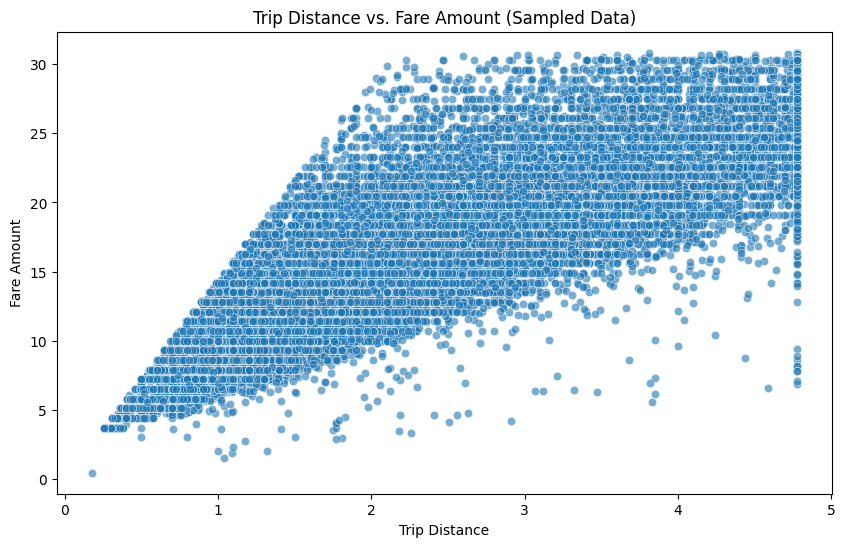

Descriptive statistics for fare_amount after all outlier removals:


,fare_amount
count,1.763290e+07
mean,1.377738e+01
std,5.993589e+00
min,2.000000e-02
25%,8.750000e+00
50%,1.280000e+01
75%,1.770000e+01
max,3.085000e+01


Descriptive statistics for trip_distance after all outlier removals:


,trip_distance
count,1.763290e+07
mean,1.960832e+00
std,1.170366e+00
min,1.000000e-02
25%,1.060000e+00
50%,1.640000e+00
75%,2.580000e+00
max,4.775000e+00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df.sample(n=50000, random_state=42), alpha=0.6)
plt.title('Trip Distance vs. Fare Amount (Sampled Data)')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.show()

print("Descriptive statistics for fare_amount after all outlier removals:")
display(df['fare_amount'].describe())
print("Descriptive statistics for trip_distance after all outlier removals:")
display(df['trip_distance'].describe())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18962717 entries, 0 to 18998027
Data columns (total 15 columns):
 #   Column                Dtype  
---  ------                -----  
 0   VendorID              uint16 
 1   passenger_count       float16
 2   trip_distance         float32
 3   PULocationID          uint16 
 4   DOLocationID          uint16 
 5   fare_amount           float32
 6   tip_amount            float16
 7   Airport_fee           float16
 8   congestion_surcharge  float16
 9   Borough               object 
 10  fare_per_mile         float32
 11  pickup_day_of_week    int32  
 12  pickup_hour           int32  
 13  pickup_month          int32  
 14  is_weekend            int64  
dtypes: float16(4), float32(3), int32(3), int64(1), object(1), uint16(3)
memory usage: 1.1+ GB


Categorical cols = ['VendorID', 'Borough', 'pickup_day_of_week', 'pickup_hour',
                    'pickup_month', 'is_weekend'
]

# VendorID

In [ ]:
df['VendorID'].value_counts()

,count
VendorID,
2,13648938
1,3821002
7,162962


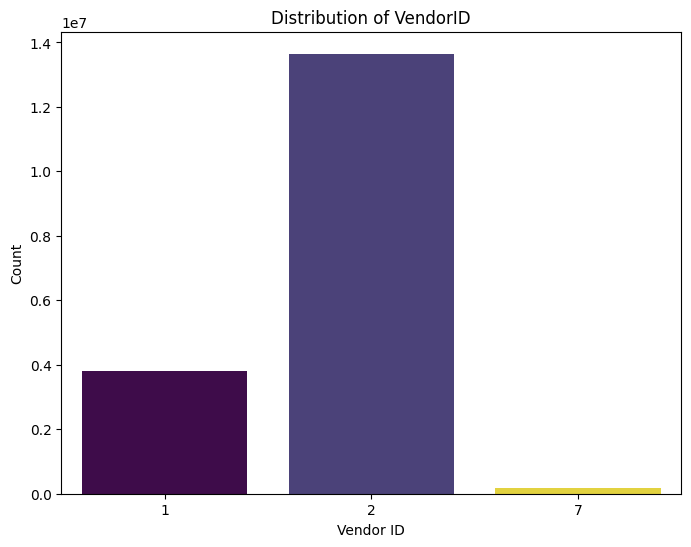

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='VendorID', data=df, hue='VendorID', palette='viridis', legend=False)
plt.title('Distribution of VendorID')
plt.xlabel('Vendor ID')
plt.ylabel('Count')
plt.show()

VendorID 2 has the most frequency

# Borough

In [ ]:
df['Borough'].value_counts()

,count
Borough,
Manhattan,16776184
Brooklyn,401638
Queens,369529
Bronx,85026
Staten Island,523
EWR,2


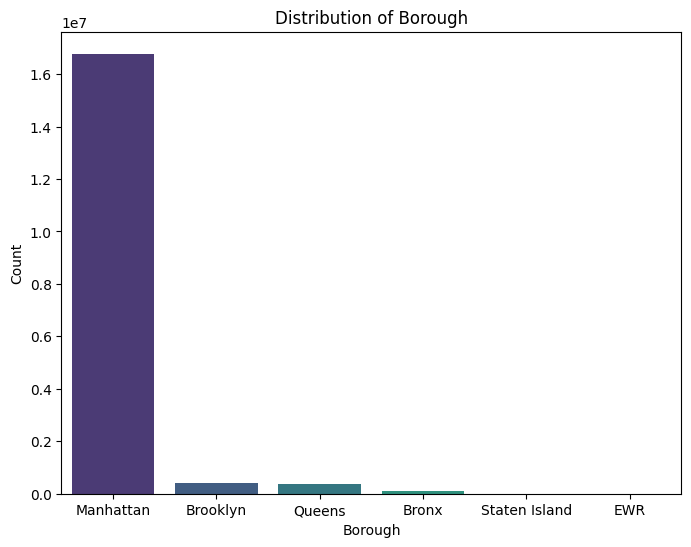

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Borough', data=df, hue='Borough', palette='viridis', legend=False)
plt.title('Distribution of Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

Manhattan is the region where the most number of taxis has operated, by knowing this we can deploy more taxis in the region more efficietly.

# pickup_day_of_week

In [ ]:
df['pickup_day_of_week'].value_counts()

,count
pickup_day_of_week,
5,2896760
3,2729744
4,2643306
2,2588073
1,2366159
6,2332806
0,2076054


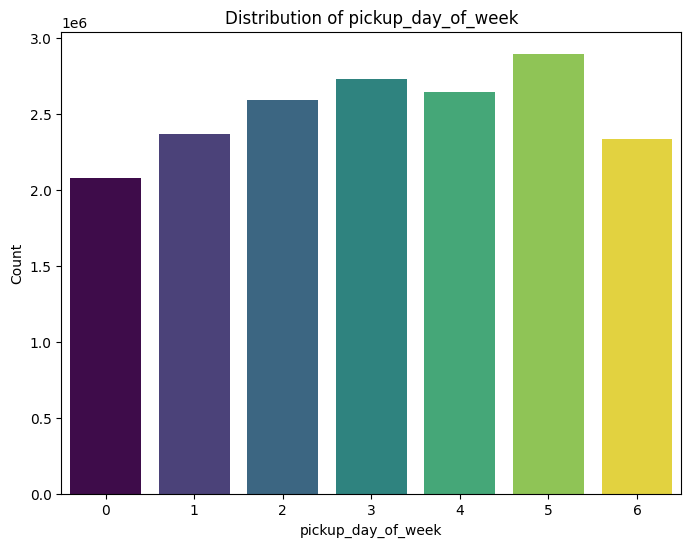

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='pickup_day_of_week', data=df, hue='pickup_day_of_week', palette='viridis', legend=False)
plt.title('Distribution of pickup_day_of_week')
plt.xlabel('pickup_day_of_week')
plt.ylabel('Count')
plt.show()

On Saturdays the demand is maximum.

# pickup_hour

In [ ]:
df['pickup_hour'].value_counts()

,count
pickup_hour,
18,1243612
17,1159437
21,1126541
19,1105524
20,1093604
22,1029574
15,1020415
16,1016878
14,973536


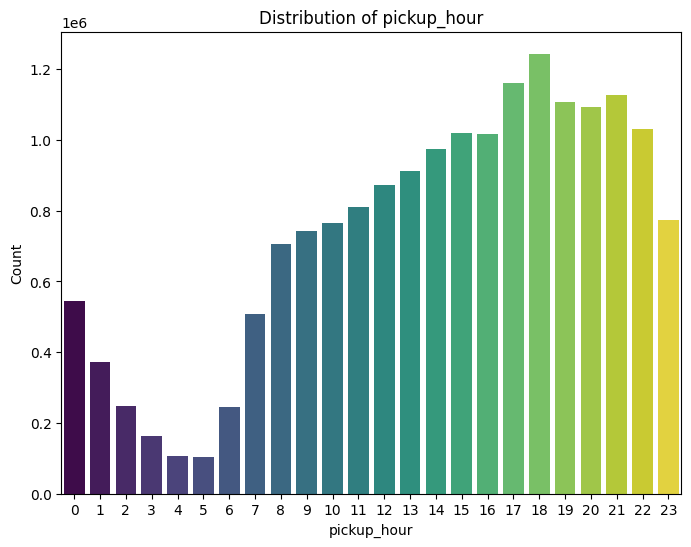

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='pickup_hour', data=df, hue='pickup_hour', palette='viridis', legend=False)
plt.title('Distribution of pickup_hour')
plt.xlabel('pickup_hour')
plt.ylabel('Count')
plt.show()

At 5:00 pm the demand is maximum, maybe because of ending office hours.

# pickup_month

In [ ]:
df['pickup_month'].value_counts()

,count
pickup_month,
5,3147894
3,3092947
6,3006714
4,2969363
2,2729588
1,2686377
12,19


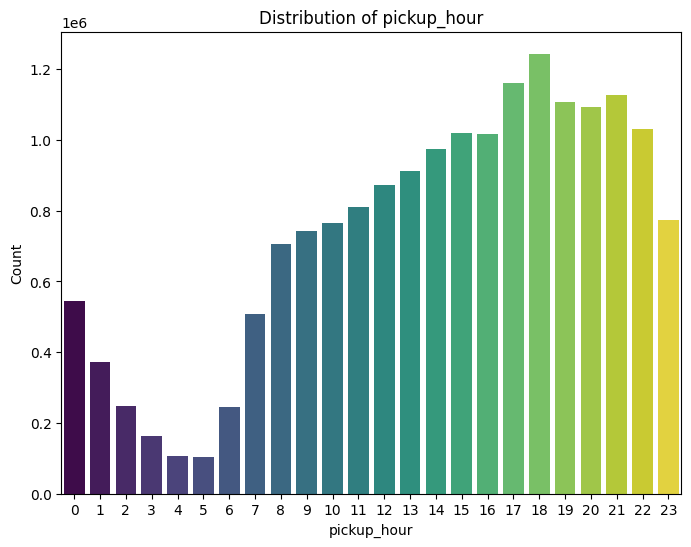

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='pickup_hour', data=df, hue='pickup_hour', palette='viridis', legend=False)
plt.title('Distribution of pickup_hour')
plt.xlabel('pickup_hour')
plt.ylabel('Count')
plt.show()

# is_weekend

In [ ]:
df['is_weekend'].value_counts()

,count
is_weekend,
0,12403336
1,5229566


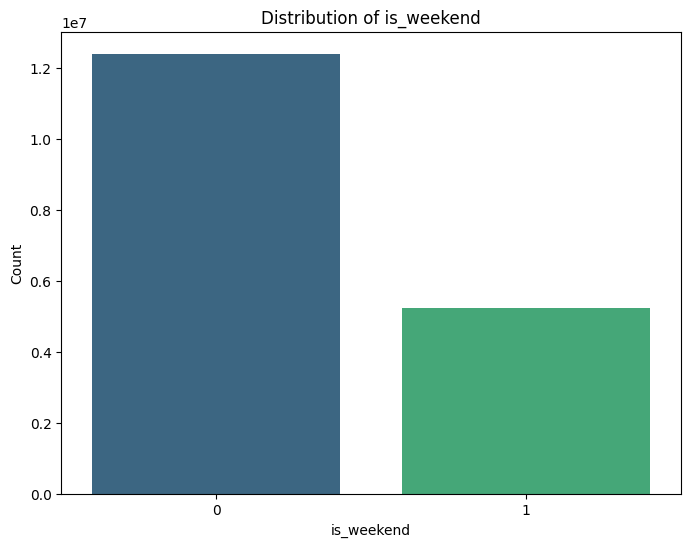

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='is_weekend', data=df, hue='is_weekend', palette='viridis', legend=False)
plt.title('Distribution of is_weekend')
plt.xlabel('is_weekend')
plt.ylabel('Count')
plt.show()

During weekdays the demand for the taxis are more which is logical.

# Correlation matrix for non-categorical features

In [ ]:
non_categorical_cols = ['trip_distance', 'fare_amount', 'tip_amount',
                      'congestion_surcharge', 'total_amount', 'Airport_fee', 'passenger_count', 'fare_per_mile']
df_corr = df[non_categorical_cols].corr()

In [ ]:
display(df_corr)

,trip_distance,fare_amount,tip_amount,congestion_surcharge,total_amount,Airport_fee,passenger_count,fare_per_mile
trip_distance,1.000000,0.894385,0.157396,-0.266693,0.768367,0.151585,-0.029642,-0.661794
fare_amount,0.894385,1.000000,0.188407,-0.254913,0.865915,0.099993,-0.023081,-0.354157
tip_amount,0.157396,0.188407,1.000000,0.527266,0.578934,0.013092,0.080883,-0.070620
congestion_surcharge,-0.266693,-0.254913,0.527266,1.000000,0.147803,-0.158297,0.160291,0.146777
total_amount,0.768367,0.865915,0.578934,0.147803,1.000000,0.102713,0.027839,-0.304175
Airport_fee,0.151585,0.099993,0.013092,-0.158297,0.102713,1.000000,0.007387,-0.102398
passenger_count,-0.029642,-0.023081,0.080883,0.160291,0.027839,0.007387,1.000000,0.021612
fare_per_mile,-0.661794,-0.354157,-0.070620,0.146777,-0.304175,-0.102398,0.021612,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

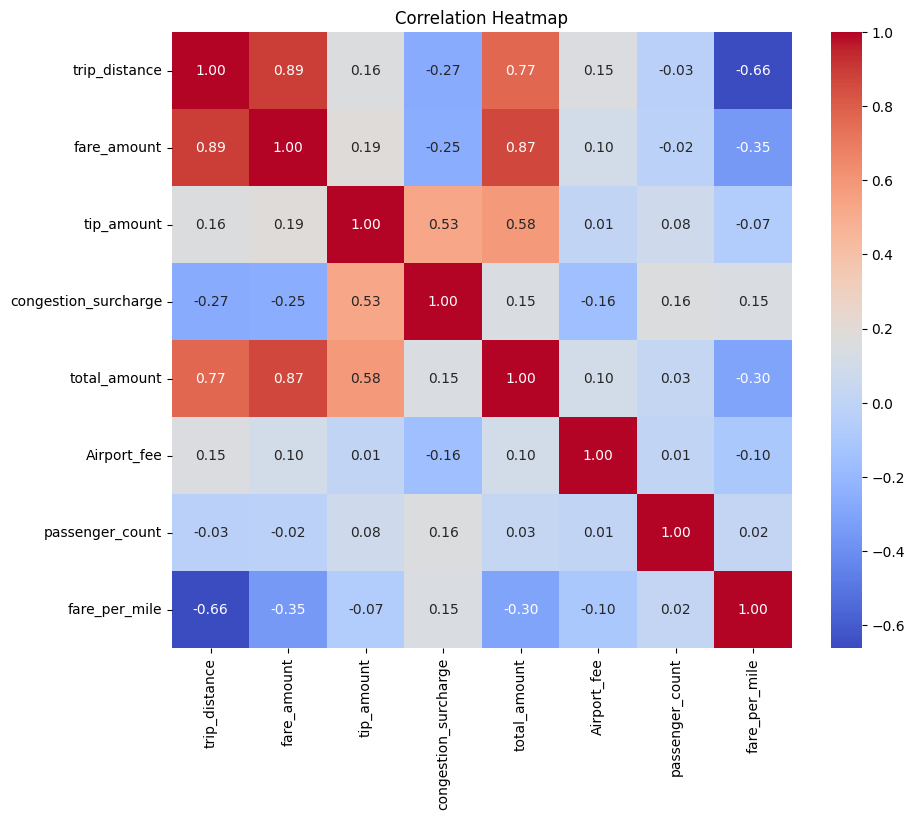

In [ ]:
# plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [ ]:
df.to_parquet('imp_features_yellow_taxi.parquet')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17632902 entries, 0 to 18998027
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   VendorID              uint16 
 1   passenger_count       float16
 2   trip_distance         float64
 3   PULocationID          uint16 
 4   DOLocationID          uint16 
 5   fare_amount           float32
 6   tip_amount            float16
 7   Airport_fee           float16
 8   congestion_surcharge  float16
 9   total_amount          float32
 10  Borough               object 
 11  fare_per_mile         float64
 12  pickup_day_of_week    int32  
 13  pickup_hour           int32  
 14  pickup_month          int32  
 15  is_weekend            int64  
dtypes: float16(4), float32(2), float64(2), int32(3), int64(1), object(1), uint16(3)
memory usage: 1.2+ GB


# Monthly trip volume vs revenue

Text(0, 0.5, 'Total Revenue')

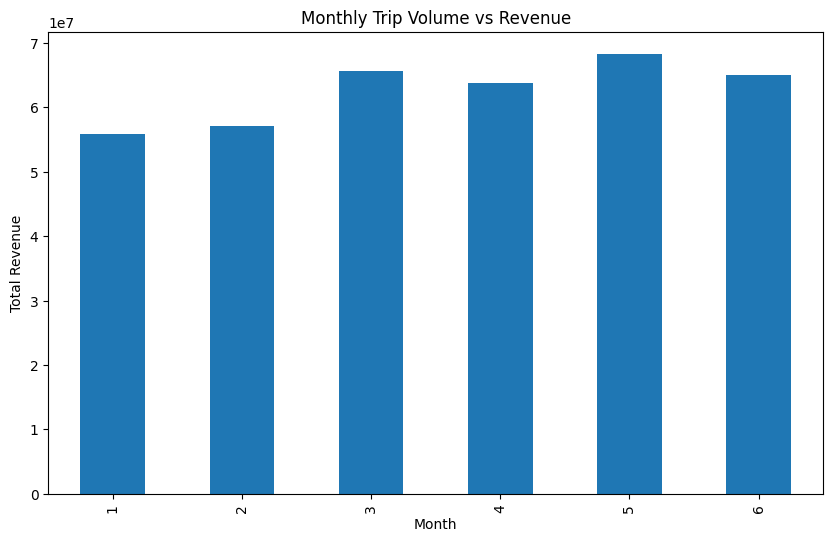

In [ ]:
df[df['pickup_month'] != 12].groupby('pickup_month')['total_amount'].sum().plot(kind='bar', figsize=(10, 6))
plt.title('Monthly Trip Volume vs Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

Revenue wise the month with the highest revenue is May followed by June and March, maybe because of the summer months.

# congestion_surcharge vs pickup_hour

Text(0.5, 0, 'pickup_hour')

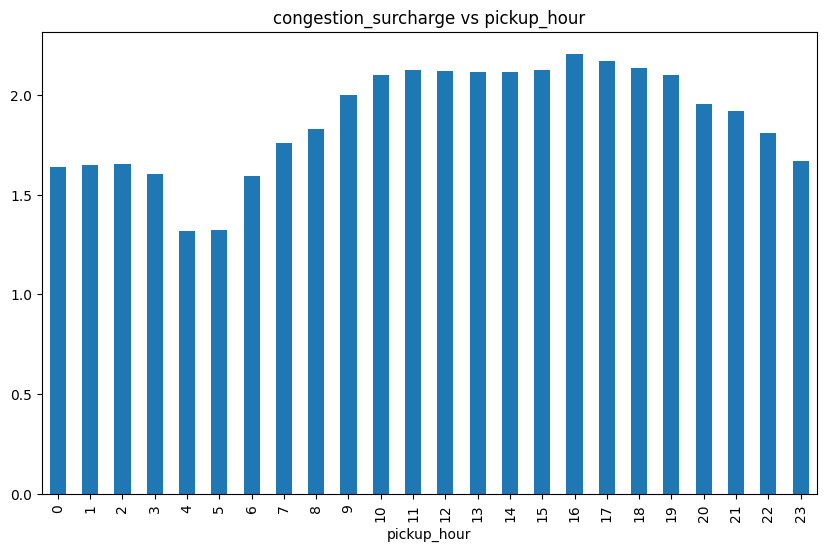

In [ ]:
df.groupby('pickup_hour')['congestion_surcharge'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('congestion_surcharge vs pickup_hour')
plt.xlabel('pickup_hour')

From the above plot we come to understand that around 4:00 PM there is peak congestion, maybe because of office hours.

# tip_amount vs pickup_hour

Text(0.5, 0, 'pickup_hour')

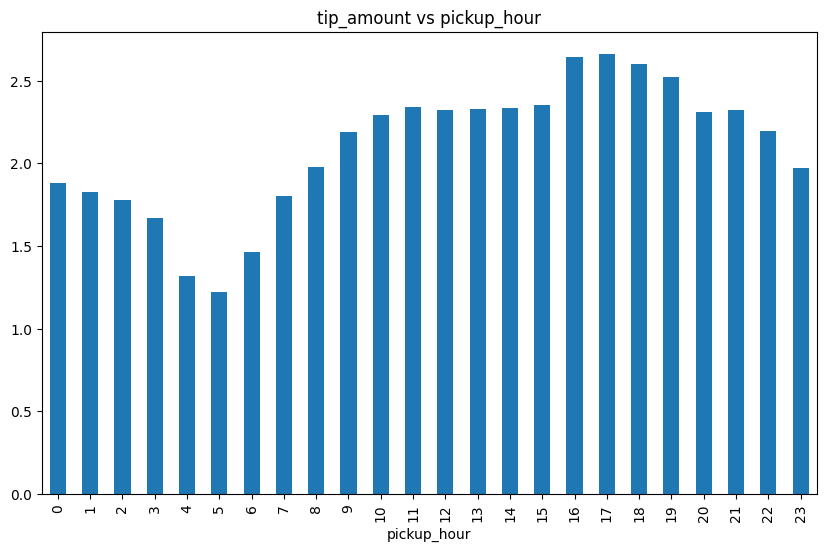

In [ ]:
df.groupby('pickup_hour')['tip_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('tip_amount vs pickup_hour')
plt.xlabel('pickup_hour')

Generally tip amount tends to be more during odd hours of the day but in this case it seems to be around 4 pm and 5 pm, the reason maybe because the demand is high during this time and drivers are asking for a greater tip amount.

# fare_amount vs is_weekend

Text(0.5, 0, 'is_weekend')

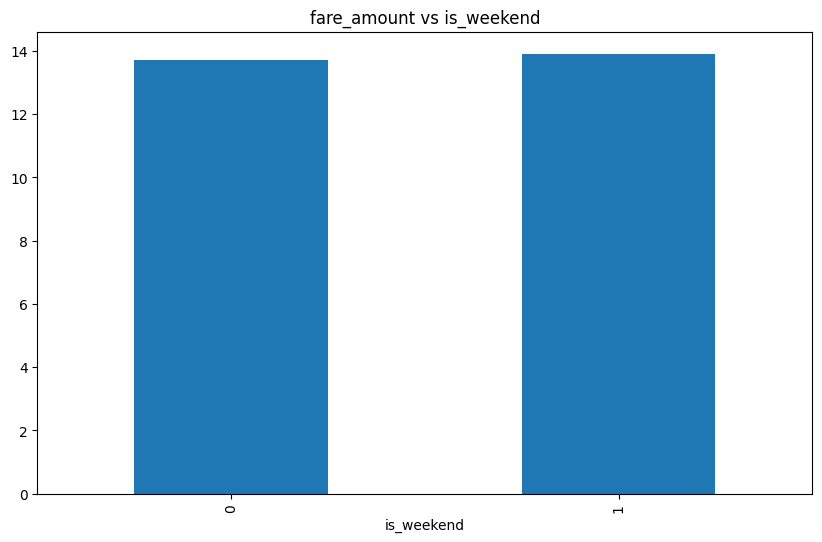

In [ ]:
df.groupby('is_weekend')['fare_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('fare_amount vs is_weekend')
plt.xlabel('is_weekend')

The fare amount tends to remain the same during weekdays and weekends

# VendorID vs fare_amount

Text(0.5, 0, 'VendorID')

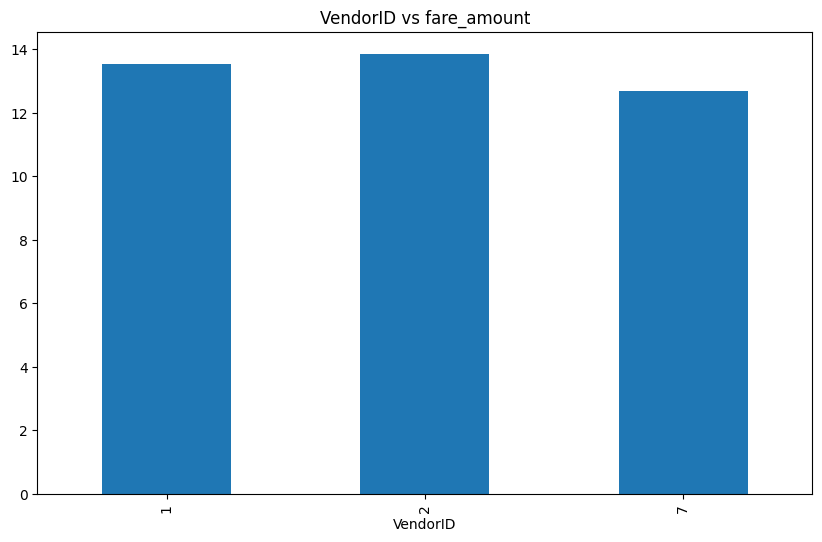

In [ ]:
df.groupby('VendorID')['fare_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('VendorID vs fare_amount')
plt.xlabel('VendorID')

The data provided by VendorID 2 has the avg fare amount

# fare_amount vs borough

Text(0.5, 0, 'Borough')

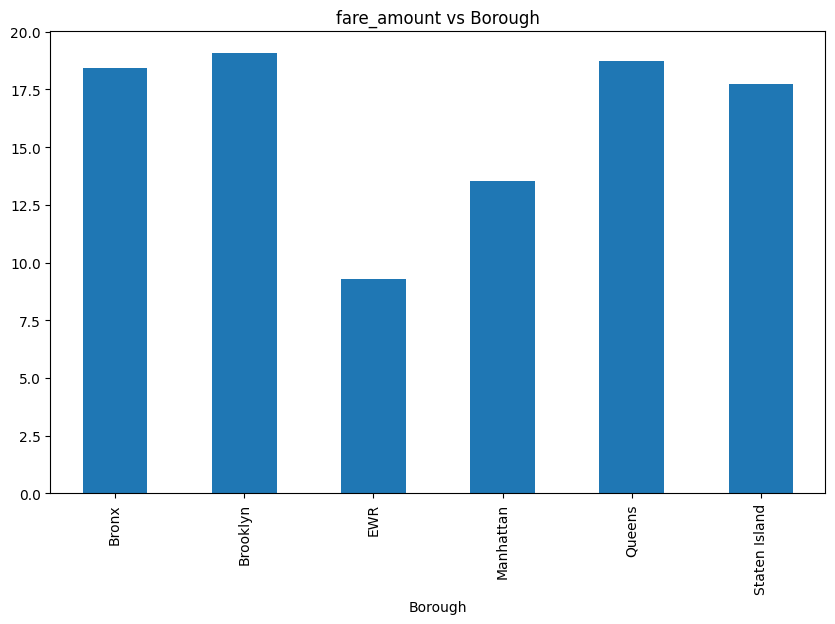

In [ ]:
df.groupby('Borough')['fare_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('fare_amount vs Borough')
plt.xlabel('Borough')

Region wise Brooklyn charges the max avg fare amount than other regions

# fare_amount vs pickup_hour

Text(0.5, 0, 'pickup_hour')

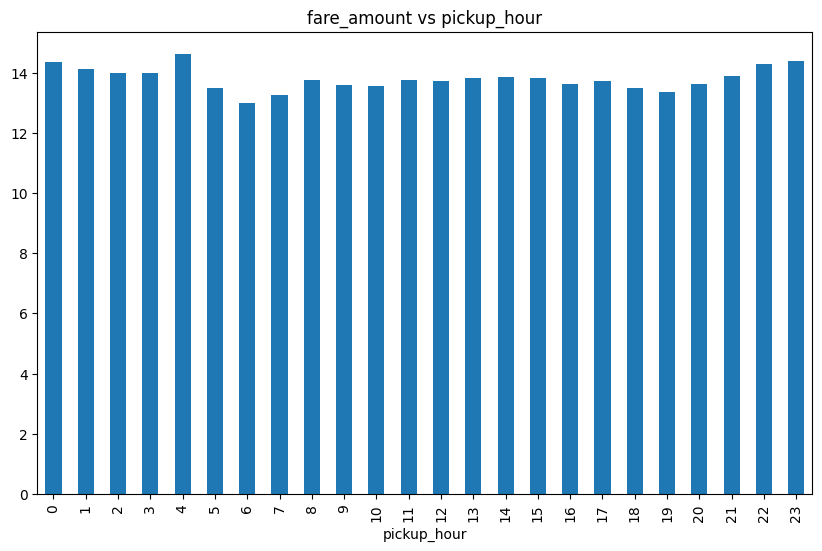

In [ ]:
df.groupby('pickup_hour')['fare_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('fare_amount vs pickup_hour')
plt.xlabel('pickup_hour')

The fare amount is max during unusual hours one around 4 AM and other around midnight, this is fair in the real world scenario charge generally goes up during these hours.

# fare_amount vs pickup_day_of_week

Text(0.5, 0, 'pickup_day_of_week')

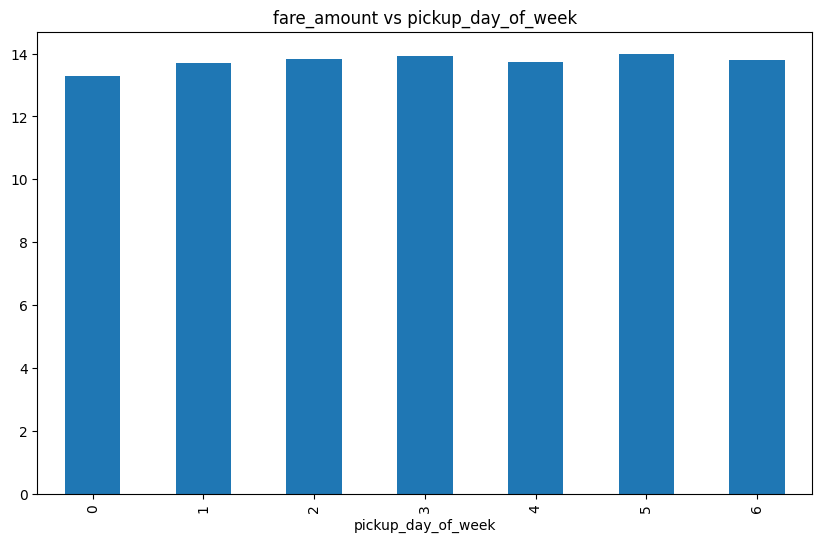

In [ ]:
df.groupby('pickup_day_of_week')['fare_amount'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('fare_amount vs pickup_day_of_week')
plt.xlabel('pickup_day_of_week')

fare amount is not proportional to pickup day, each day the rpicing remains almost same.

# average distance covered vs pickup_day_of_week

Text(0.5, 0, 'pickup_day_of_week')

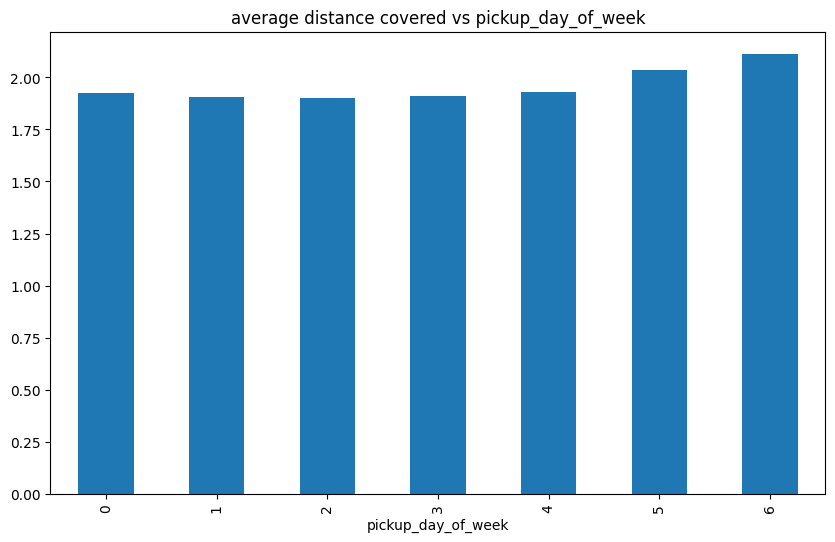

In [ ]:
df.groupby('pickup_day_of_week')['trip_distance'].mean().plot(kind='bar', figsize=(10, 6))
plt.title('average distance covered vs pickup_day_of_week')
plt.xlabel('pickup_day_of_week')

During weekday the average distance remains same the reason midght be taxis are being availed only for office purpose while on weekends the distance gets increased maybe because of vacation or a short trip

### Average Number of Trips vs. `pickup_day_of_week`

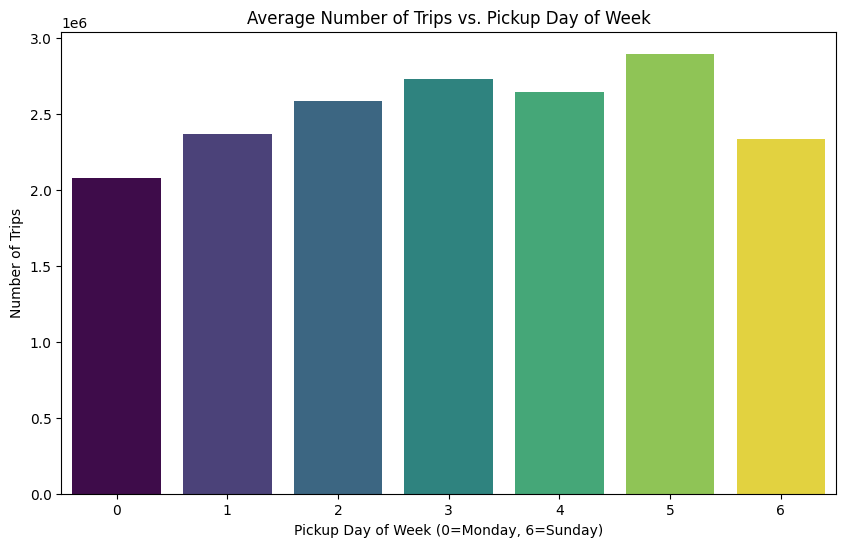

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_day_of_week', data=df, hue='pickup_day_of_week', palette='viridis', legend=False)
plt.title('Average Number of Trips vs. Pickup Day of Week')
plt.xlabel('Pickup Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Trips')
plt.show()

The max number of trips have been availed on saturdays 

# Hourly demand heatmap (weekday vs weekend)

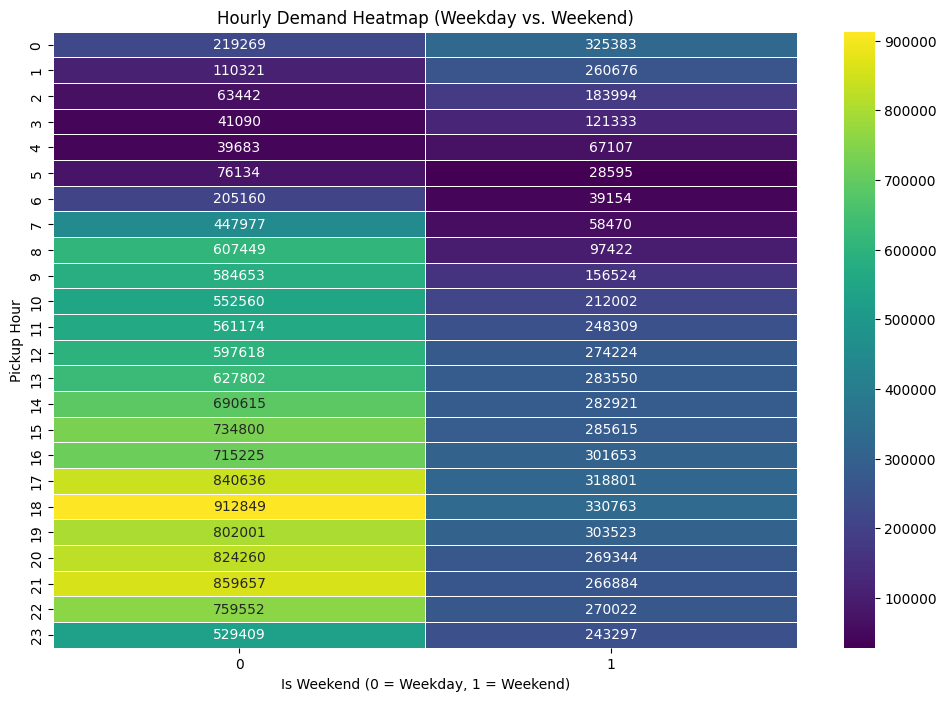

In [ ]:
demand_data = df.groupby(['pickup_hour', 'is_weekend']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(demand_data, cmap='viridis', annot=True, fmt='d', linewidths=.5)
plt.title('Hourly Demand Heatmap (Weekday vs. Weekend)')
plt.xlabel('Is Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Pickup Hour')
plt.show()

# Monthly trip volume

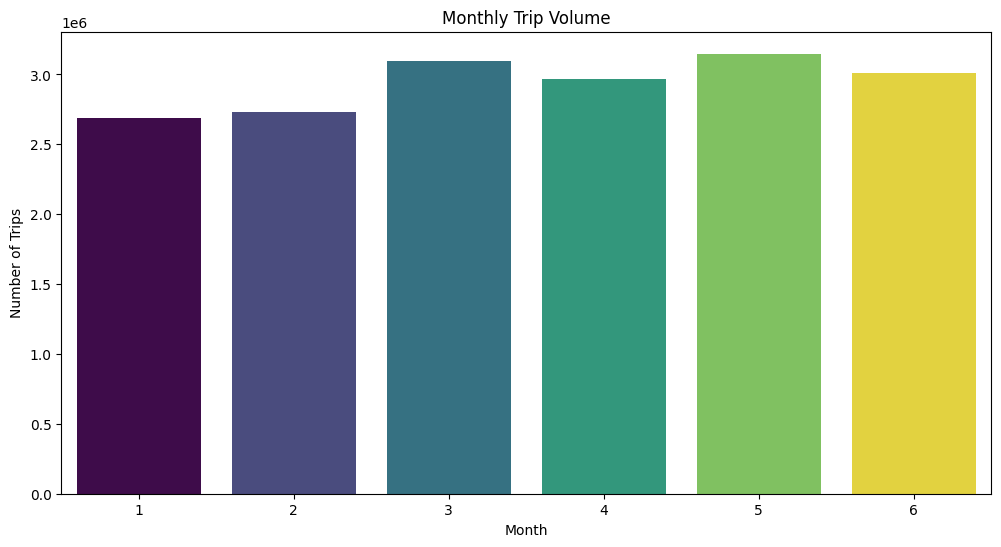

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_month', data=df[df['pickup_month'] != 12], hue='pickup_month', palette='viridis', legend=False)
plt.title('Monthly Trip Volume')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.show()

March and May has the most number of trips.

## Statistical Tests

### 1. Chi-squared Test for Independence

**Purpose:** To determine if there is a significant association between two categorical variables.

**Scenario:** We want to check if `VendorID` is independent of the `Borough` where the pickup occurred. In other words, are certain vendors more prevalent in specific boroughs?

H0: There is no association between VendorID and Borough

H1: The is atleast some association between VendorID and Borough

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['VendorID'], df['Borough'])

display(contingency_table)

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant association between VendorID and Borough.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant association between VendorID and Borough.")

Borough,Bronx,Brooklyn,EWR,Manhattan,Queens,Staten Island
VendorID,,,,,,
1,24075,111766,2,3609935,75137,87
2,60932,289581,0,13004918,293071,436
7,19,291,0,161331,1321,0



Chi-squared Statistic: 16727.94
P-value: 0.000
Degrees of Freedom: 10
Conclusion: Reject the null hypothesis. There is a significant association between VendorID and Borough.


### 2. Independent Samples T-test

**Purpose:** To compare the means of a numerical variable between two independent groups.

**Scenario:** We want to determine if there is a significant difference in the average `fare_amount` between rides taken on weekdays (`is_weekend` = 0) and rides taken on weekends (`is_weekend` = 1).

H0: There is no significant differences between fare_amount and weekdays.

H1: There is atleast some difference between fare_amount and weekdays.

In [ ]:
from scipy.stats import ttest_ind

# Separate the fare_amount for weekdays and weekends
fare_weekday = df[df['is_weekend'] == 0]['fare_amount']
fare_weekend = df[df['is_weekend'] == 1]['fare_amount']

# Perform independent samples t-test
statistic, p_value = ttest_ind(fare_weekday, fare_weekend, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount between weekdays and weekends.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average fare amount between weekdays and weekends.")

T-statistic: -58.39
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount between weekdays and weekends.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17632902 entries, 0 to 18998027
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   VendorID              uint16 
 1   passenger_count       float16
 2   trip_distance         float64
 3   PULocationID          uint16 
 4   DOLocationID          uint16 
 5   fare_amount           float32
 6   tip_amount            float16
 7   Airport_fee           float16
 8   congestion_surcharge  float16
 9   total_amount          float32
 10  Borough               object 
 11  fare_per_mile         float64
 12  pickup_day_of_week    int32  
 13  pickup_hour           int32  
 14  pickup_month          int32  
 15  is_weekend            int64  
dtypes: float16(4), float32(2), float64(2), int32(3), int64(1), object(1), uint16(3)
memory usage: 1.2+ GB


### 3. ANOVA (Analysis of Variance) Test

**Purpose:** To determine if there are statistically significant differences between the means of three or more independent groups for a numerical outcome variable.

**Scenario:** We want to investigate if the average `fare_amount` differs significantly depending on the `pickup_hour`. Each `pickup_hour` (0 to 23) represents a different group, and `fare_amount` is the numerical outcome.

H0: There is no association between fare_amount and pickup_hour

H1: There is atleast some association between fare_amount and pickup_hour

In [ ]:
from scipy.stats import f_oneway

# Group fare_amount by pickup_hour
hourly_fares = [df['fare_amount'][df['pickup_hour'] == hour] for hour in df['pickup_hour'].unique()]

# Filter out any empty groups (if a particular hour has no data)
hourly_fares = [fares for fares in hourly_fares if not fares.empty]

# Perform ANOVA test
# If there are less than 2 groups with data, f_oneway will raise an error, handle this case.
if len(hourly_fares) >= 2:
    f_statistic, p_value = f_oneway(*hourly_fares)

    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different pickup hours.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average fare amount across different pickup hours.")
else:
    print("Not enough groups with data to perform ANOVA test for pickup_hour.")

F-statistic: 1865.53
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different pickup hours.


### 4. ANOVA (Analysis of Variance) Test for `pickup_month`

**Purpose:** To determine if there are statistically significant differences between the means of the `fare_amount` across different `pickup_month` categories.

**Scenario:** We will investigate if the average `fare_amount` varies significantly depending on the `pickup_month`. Each month (1 to 12) represents a different group.

H0: The average fare amount does not vary significantly depending on the pickup month.

H1: The average fare amount varies significantly depending on the pickup month.

In [ ]:
from scipy.stats import f_oneway

# Group fare_amount by pickup_month
monthly_fares = [df['fare_amount'][df['pickup_month'] == month] for month in df['pickup_month'].unique()]

# Filter out any empty groups
monthly_fares = [fares for fares in monthly_fares if not fares.empty]

# Perform ANOVA test
if len(monthly_fares) >= 2:
    f_statistic, p_value = f_oneway(*monthly_fares)

    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different pickup months.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average fare amount across different pickup months.")
else:
    print("Not enough groups with data to perform ANOVA test for pickup_month.")

F-statistic: 15612.40
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different pickup months.


### 5. ANOVA (Analysis of Variance) Test for `pickup_day_of_week`

**Purpose:** To determine if there are statistically significant differences between the means of the `fare_amount` across different `pickup_day_of_week` categories.

**Scenario:** We will investigate if the average `fare_amount` varies significantly depending on the `pickup_day_of_week`. Each day of the week (0 to 6) represents a different group.

H0: The average fare amount doest not vary with the pickup day of week

H1: The avergae fare amount vary with the pickup day of week

In [ ]:
from scipy.stats import f_oneway

# Group fare_amount by pickup_day_of_week
daily_fares = [df['fare_amount'][df['pickup_day_of_week'] == day] for day in df['pickup_day_of_week'].unique()]

# Filter out any empty groups
daily_fares = [fares for fares in daily_fares if not fares.empty]

# Perform ANOVA test
if len(daily_fares) >= 2:
    f_statistic, p_value = f_oneway(*daily_fares)

    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different days of the week.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average fare amount across different days of the week.")
else:
    print("Not enough groups with data to perform ANOVA test for pickup_day_of_week.")

F-statistic: 3291.56
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different days of the week.


### 6. ANOVA (Analysis of Variance) Test for `fare_amount` vs. `Borough`

**Purpose:** To determine if there are statistically significant differences between the means of the `fare_amount` across different `Borough` categories.

**Scenario:** We will investigate if the average `fare_amount` varies significantly depending on the `Borough`.

H0: The average fare amount does not vary with borough.

H1: The average fare amount varies with borough.

In [ ]:
from scipy.stats import f_oneway

# Group fare_amount by Borough
borough_fares = [df['fare_amount'][df['Borough'] == borough] for borough in df['Borough'].unique()]

# Filter out any empty groups
borough_fares = [fares for fares in borough_fares if not fares.empty]

# Perform ANOVA test
if len(borough_fares) >= 2:
    f_statistic, p_value = f_oneway(*borough_fares)

    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different boroughs.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average fare amount across different boroughs.")
else:
    print("Not enough groups with data to perform ANOVA test for Borough.")

F-statistic: 128356.60
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in average fare amount across different boroughs.


### 8. ANOVA (Analysis of Variance) Test for `Airport_fee` vs. `pickup_hour`

**Purpose:** To determine if there are statistically significant differences between the means of the `Airport_fee` across different `pickup_hour` categories.

**Scenario:** We will investigate if the average `Airport_fee` varies significantly depending on the `pickup_hour`. Each `pickup_hour` (0 to 23) represents a different group.

H0: The average airport fee does not vary with pickup hour

H1: The average airport fee varies with pickup hour.

In [ ]:
from scipy.stats import f_oneway
import numpy as np

# Group Airport_fee by pickup_hour
grouped_airport_fee_by_hour = {hour: df['Airport_fee'][df['pickup_hour'] == hour] for hour in df['pickup_hour'].unique()}

# Filter out empty groups and groups with zero variance
valid_hourly_airport_fees = []
problematic_hours_airport_fee = []
for hour, fees in grouped_airport_fee_by_hour.items():
    if not fees.empty:
        # Check if the standard deviation is greater than 0 (meaning variance is also greater than 0)
        if fees.std() > 0:
            valid_hourly_airport_fees.append(fees)
        else:
            problematic_hours_airport_fee.append(hour)

# Perform ANOVA test
if len(valid_hourly_airport_fees) >= 2:
    f_statistic, p_value = f_oneway(*valid_hourly_airport_fees)

    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("Conclusion: Reject the null hypothesis. There is a significant difference in average Airport fee across different pickup hours (considering only hours with varying fees).")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in average Airport fee across different pickup hours (considering only hours with varying fees).")

    if problematic_hours_airport_fee:
        print(f"\nNote: ANOVA could not be performed for pickup hours {sorted(problematic_hours_airport_fee)} because Airport fees were constant (e.g., all 0.0 or all 1.75) for these hours.")
else:
    print("Not enough groups with sufficient variance to perform ANOVA test for Airport_fee vs pickup_hour.")

F-statistic: nan
P-value: nan
Conclusion: Fail to reject the null hypothesis. There is no significant difference in average Airport fee across different pickup hours (considering only hours with varying fees).


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18775304 entries, 0 to 18998027
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   Zone                   object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     float16       
 17  congestion_surcharge   float64       
 18  total_amount           fl

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18454364 entries, 0 to 18998027
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   Zone                   object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     float16       
 17  congestion_surcharge   float64       
 18  total_amount           fl

In [ ]:
# Rename the 'Zone' column to 'pickup_zone'
df.rename(columns={'Zone': 'pickup_zone'}, inplace=True)

# Display the DataFrame's info to confirm the column name change
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18454364 entries, 0 to 18998027
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   pickup_zone            object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     float16       
 17  congestion_surcharge   float64       
 18  total_amount           fl

In [ ]:
# Merge df with df_zones to get the drop-off zone information
df = pd.merge(df, df_zones[['LocationID', 'Zone']], left_on='DOLocationID', right_on='LocationID', how='left')

# Rename the 'Zone' column (from df_zones) to 'drop_location'
df.rename(columns={'Zone': 'drop_location'}, inplace=True)

# Drop the redundant 'LocationID' column that resulted from the merge
df.drop(columns=['LocationID'], inplace=True)

print("DataFrame after joining with zonelookup and renaming 'Zone' to 'drop_location':")
df.info()

DataFrame after joining with zonelookup and renaming 'Zone' to 'drop_location':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18454364 entries, 0 to 18454363
Data columns (total 25 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               uint16        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   payment_type           uint16        
 5   trip_distance          float32       
 6   PULocationID           uint16        
 7   DOLocationID           uint16        
 8   pickup_zone            object        
 9   fare_amount            float32       
 10  extra                  float16       
 11  mta_tax                float16       
 12  tip_amount             float16       
 13  tolls_amount           float16       
 14  improvement_surcharge  float16       
 15  Airport_fee            float64       
 16  cbd_congestion_fee     flo

In [ ]:
df.to_parquet('final_yellow_taxi_2025.parquet')